# Free boundary computation

This file compute the free-boundary case using the optimized PF coils and radial ratios obtained in fixed boundary. Results obtained are compared with ones from `DIIID_baseline_ex.ipynb`, which can be find in https://github.com/OpenFUSIONToolkit/OpenFUSIONToolkit/tree/main/src/examples/TokaMaker/DIIID

---

## DIII-D equilibria
- $\textbf{g192185.02440}$
- $\textbf{g174864.02500}$
- $\textbf{g173630.03000}$


# Loading libraries

## Useful libraries

In [1]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt

from helper_fct import ( 
    resize_polygon, place_points, update_boundary, plot_coil
)

plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [2]:
#sys.path.append('/Applications/OpenFUSIONToolkit/python')
home_dir = os.path.expanduser("~")
oft_root_path = os.path.join(home_dir, "OpenFUSIONToolkit/install_release")
os.environ["OFT_ROOTPATH"] = oft_root_path

tokamaker_python_path = os.getenv("OFT_ROOTPATH")

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
    
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain, save_gs_mesh, load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

## 1. Coil position space & machine geometry

The following cell creates the bounds defining the $\textbf{coil position space}$ (CPS). The latter is defined as the area between the curves `coil_center_cand1` & `coil_center_cand2`. Tune these 2 variables to modify the CPS

In [3]:
# Loading machine LCFS & shot from EQDSK file
eqdsk = read_eqdsk('examples/data/eqdsk/g192185.02440') # Machine shot
LCFS_contour = eqdsk['rzout'].copy()

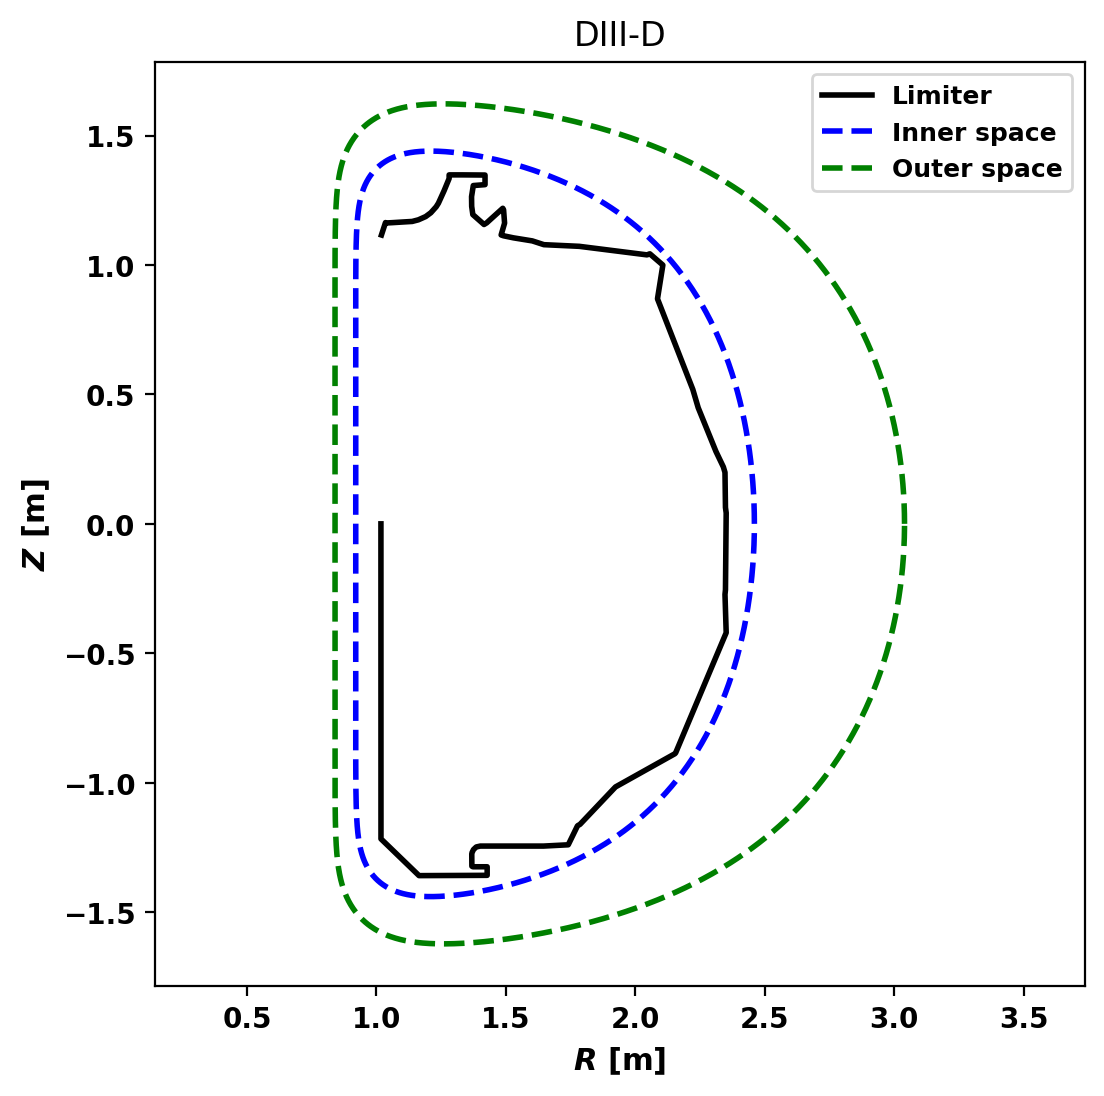

In [4]:
# Geometry
with open('ignore/DIII_D_orig/DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Get the machine limiter
lim0 = np.array(DIIID_geom['limiter'])

### generates a simplified limiter (return a list of (R,Z) coord of plasma bound.)
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) # DIII-D

# inner position space
lim1 = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) # DIII-D  
coil_center_cand1 = resize_polygon(lim1, dx=0.1)

# outer position space
lim2 = update_boundary(r0=1.94, z0=0, a0=0.95, kappa=1.55, delta=0.8, squar=0.15, npts=1700) # DIII-D 
coil_center_cand2 = resize_polygon(lim2, dx=0.15)     

# Plot geometry & coil position space
plt.figure(figsize=(6, 6))
plt.plot(lim0[:,0], lim0[:,1], 'k', label='Limiter')
#plt.plot(lim1[:,0], lim1[:,1], 'r--', label='Simpler limiter')
plt.plot(coil_center_cand1[:,0], coil_center_cand1[:,1], 'b--', label='Inner space')
plt.plot(coil_center_cand2[:,0], coil_center_cand2[:,1], 'g--', label='Outer space')

plt.title('DIII-D')
plt.xlabel('$R$ [m]', fontsize=11)
plt.ylabel('$Z$ [m]', fontsize=11)
plt.axis('equal')
plt.legend(fontsize=9)

In [5]:
def place_points_pol_rad(ncoils, arc_inner, arc_outer, pol_angles, radials):
    """
    Places coils inside a strip defined by two curves (arc_inner, arc_outer)
    based on poloidal angle and radial offset.

    Parameters:
        - ncoils : (int) Number of coils in upper side
        - arc_inner : ndarray (N,2)
        - Inner curve coordinates (R,Z)
        - arc_outer : ndarray (N,2)
        - Outer curve coordinates (R,Z) 
        - pol_angles : Poloidal angles (degrees)
        - radials : Radial ratios

    Returns
        - inds : Indices along the arc (based on arc_inner indexing).
        - locs : ndarray (ncoils,2) Coil (R,Z) coordinates.
    """
    if len(pol_angles) != ncoils or len(radials) != ncoils:
        raise ValueError("Length of pol_angles and radials must match ncoils.")

    # Create a mapping from poloidal angle to index along arc
    theta_range = np.linspace(0, 180, len(arc_inner))  # top half
    pol_angles = np.asarray(pol_angles)

    inds = []
    locs = []

    for theta, rho in zip(pol_angles, radials):
        # Interpolate R and Z along each arc at this theta
        R_inner = np.interp(theta, theta_range, arc_inner[:, 0])
        Z_inner = np.interp(theta, theta_range, arc_inner[:, 1])
        R_outer = np.interp(theta, theta_range, arc_outer[:, 0])
        Z_outer = np.interp(theta, theta_range, arc_outer[:, 1])

        # Interpolate between inner and outer curves based on rho
        R_pos = (1 - rho) * R_inner + rho * R_outer
        Z_pos = (1 - rho) * Z_inner + rho * Z_outer

        # Approximate index based on inner arc position
        idx = int(np.interp(theta, theta_range, np.arange(len(arc_inner))))

        inds.append(idx)
        locs.append([R_pos, Z_pos])

    return np.array(inds), np.array(locs)

In [6]:
def make_new_coils(params, nCoils, dx=0.08, dy=0.08, params2=None, ifplot=True):
    """
    Generates and places poloidal field (PF) coils given their poloidal angles and radial ratios. 
    It creates a set of coil pairs (one above and one below the midplane) whose size can be changed 
    thanks to dx & dy. Optionally plots two coil configurations.

    Parameters:
        - params: list of poloidal angles (degrees) and their radial ratios (between 0 and 1)
        - nCoils: Number of coils (in the top-side)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - params2: (Optional) second list of poloidal angles and radial ratios
        - ifplot: Boolean, whether to plot the given coil distribution

    Returns:
        - scan_geom (dictionary): Dict. containing the data of the coil distr.
    """
    # Loading poloidal angles (thetas) and radial ratios (radials)
    thetas = params[:nCoils]
    radials = params[nCoils:2*nCoils]
    
    # Creating dict.
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas, radials)
    
    # Creating coil pairs for (1st) distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    # Plotting the coil distribution
    if ifplot:
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        #plt.plot(lim1[:, 0], lim1[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                #plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')

        # If provided, plot the (2nd) distrib in red
        if params2 is not None:
            thetas2 = params2[:nCoils]
            radials2 = params2[nCoils:2*nCoils]

            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas2, radials2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for the 2nd distrib
                scan_geom_2["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils 
            for coil in scan_geom_2["coils"]:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    #plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')


    return scan_geom

# 2. Meshing

### Set mesh resolution for each region
First we define some target sizes to set the resolution in our free-boundary grid. These variables will be used later and represent the target edge size within a given region, where units are in meters

In [7]:
plasma_dx = 0.01
coil_dx = 0.005
vac_dx = 0.04
vv_dx = 0.04

Load here the optimized configuration of PF coils in upper-side and radial ratios obtained in the $\textbf{fixed boundary case}$

In [8]:
from pathlib import Path

for f in Path('examples/comparisons/closed_boundary_DIIID/free_boundary_test/').rglob('*.json'):
    print(f)
    results = json.loads(f.read_text())
    for method in results["methods"]:
        print(results["methods"][method]["parameters"])


examples/comparisons/closed_boundary_DIIID/free_boundary_test/lambda:1e-07,coils:4 copy/run_00/results.json
{'thetas': [130.10552298600658, 52.973966832912446, 16.330566850884775, 147.5737264990956], 'radials': [0.0, 0.4651345636996718, 0.4242794751100666, 0.019616266628504103]}
{'thetas': [52.92475168056597, 16.32892858009234, 147.48465893916475, 130.3539167294957], 'radials': [0.4624016099222366, 0.42414791858231976, 0.00012181336740633311, 0.0]}


In [9]:

# top_coils = [7.9550895237158805, 18.689102632474277, 47.6967448776751, 171.6356210910371, 177.65850865332487]
# radials = [0.051990612458852364, 0.0, 0.0, 0.0, 0.2544729904764001]

top_coils = [130.10552298600658, 52.973966832912446, 16.330566850884775, 147.5737264990956]
radials = [0.0, 0.4651345636996718, 0.4242794751100666, 0.019616266628504103]
params = top_coils + radials

Loading th PF coils informations for creating the mesh

In [10]:
scan_geom_DIIID = make_new_coils(params, len(params) // 2, dx=0.03, dy=0.03, ifplot=False)

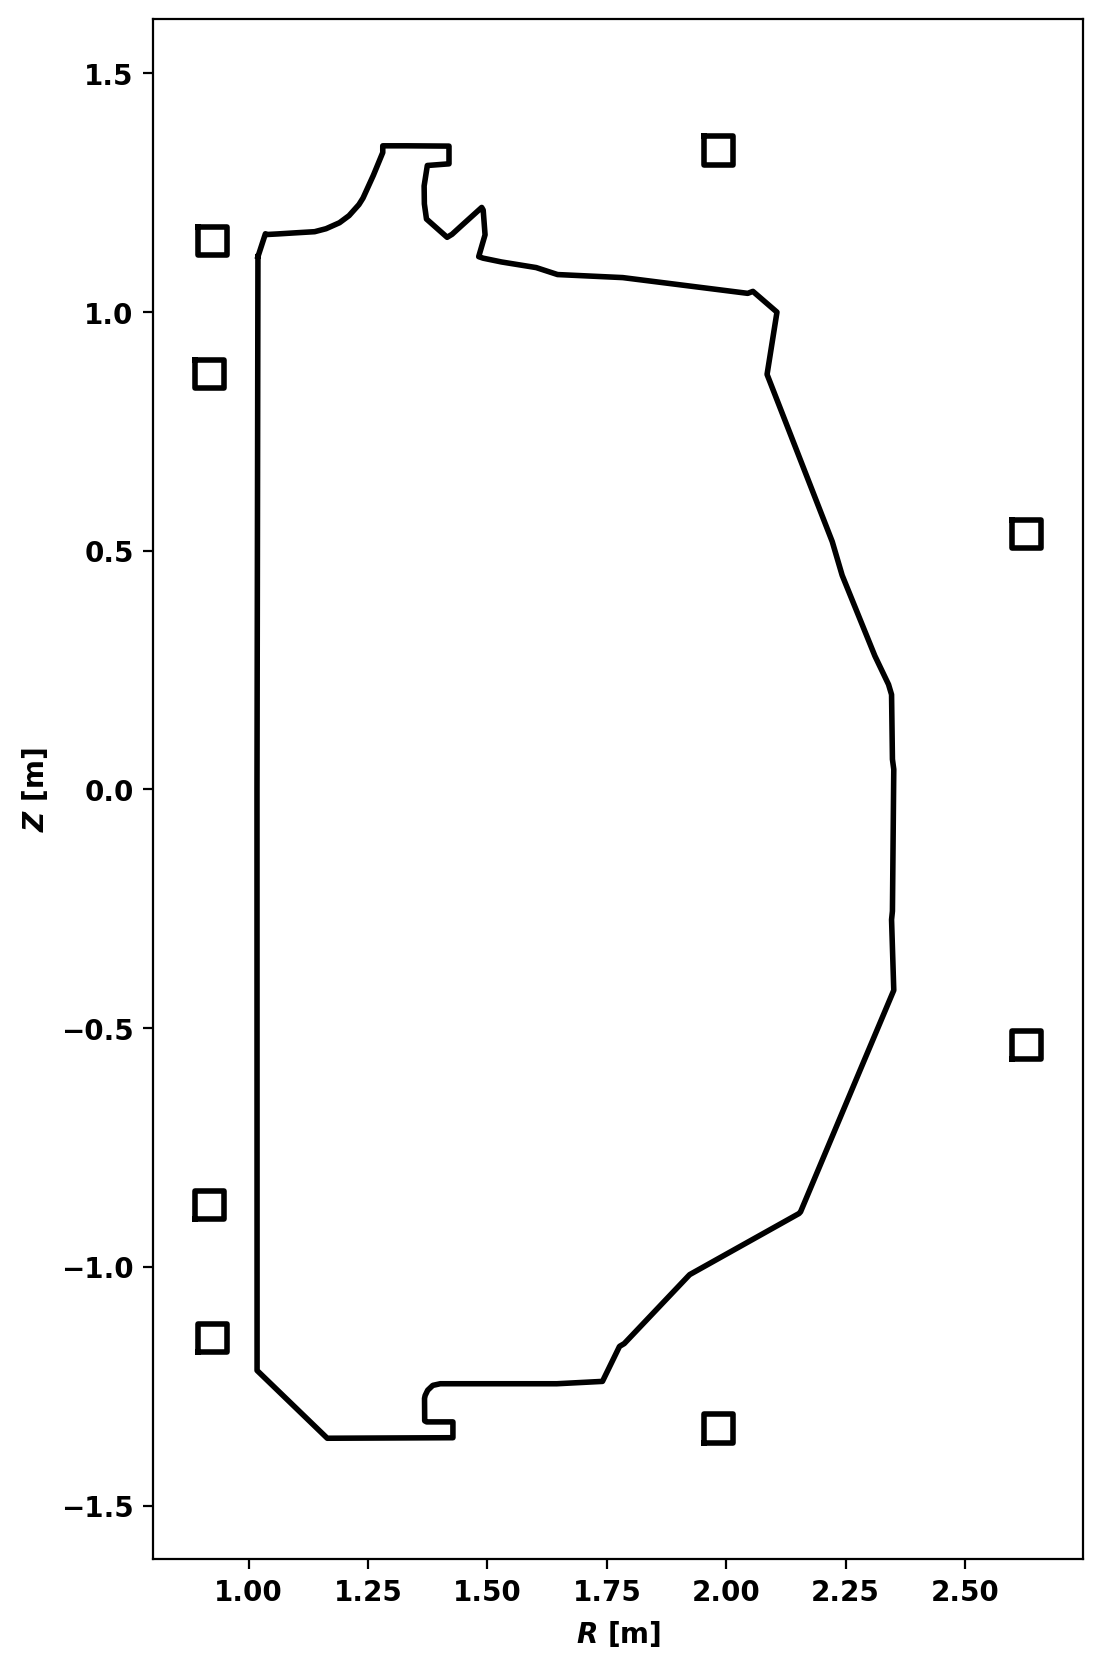

In [11]:
# Visualization
_ = make_new_coils(params, len(params) // 2, dx=0.03, dy=0.03, ifplot=True)

### Create mesh
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. Additionally, if `coil` and/or `conductor` regions are defined the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_coils "get_coils" and \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.get_conductors "get_conductors" methods should also be called to get descriptive dictionaries for later use in TokaMaker. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

### Plot resulting regions and grid
We now plot the mesh by region to inspect proper generation.

In [12]:
# Creates a Grad-Shafranov (GS) mesh domain for the magnetic equilibrium
def make_mesh(DIIID_geom, scan_geom, savename = 'DIIID_mesh_scantest.h5', ifplot = True):
    
    # Create a G-S domain
    gs_mesh = gs_Domain()
    # Define region information for mesh
    gs_mesh.define_region('air',vac_dx,'boundary')                     # Define the bounding region
    gs_mesh.define_region('plasma',plasma_dx,'plasma')                 # Define the plasma region and resolution
    gs_mesh.define_region('vacuum',vv_dx,'vacuum',allow_xpoints=True)  # Define the vacuum inside the VV
    gs_mesh.define_region('vv',vv_dx,'conductor',eta=6e-07)            # Define one region for VV 

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        if key.startswith('ECOIL'):
            for i, subcoil in enumerate(coil):
                gs_mesh.define_region('{0}_{1}'.format(key,i),coil_dx,'coil',coil_set=key,nTurns=subcoil["nturns"])
        else:
            gs_mesh.define_region(key,coil_dx,'coil',nTurns=coil["nturns"])

    # Define geometry, using the fake limiter
    gs_mesh.add_polygon(lim,'plasma',parent_name='vacuum') 
    gs_mesh.add_annulus(resize_polygon(lim, 0.01),'vacuum',resize_polygon(lim, 0.05),'vv')
    
    gs_mesh.add_enclosed([1.75,1.25],'vacuum')

    # Define each of the PF coils
    for key, coil in scan_geom["coils"].items():
        gs_mesh.add_polygon(coil["pts"],key,parent_name='air')

    # Create mesh
    mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()
    coil_dict = gs_mesh.get_coils()
    cond_dict = gs_mesh.get_conductors()

    # Plot result
    if ifplot:
        fig, ax = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)
        gs_mesh.plot_mesh(fig,ax)

    # Save mesh for later use
    save_gs_mesh(mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict,savename) # Save G-S mesh to file in HDF5 format (.h5)

    return coil_dict, cond_dict

### LETS ADD A SOLENOID CURRENT ###

In [13]:
# add this later 

# # ECOILA position
# scan_geom_DIIID['coils']['E0'] = {}
# scan_geom_DIIID['coils']['E0']['pts'] = np.array([[0.658165, -1.57925], [0.716835, -1.57925], [0.716835, 1.57925], [0.658165, 1.57925]])
# scan_geom_DIIID['coils']['E0']['nturns'] = 1.0

# # ECOILB position
# scan_geom_DIIID['coils']['E1'] = {}
# scan_geom_DIIID['coils']['E1']['pts'] = np.array([[0.728165, -1.57925], [0.786835, -1.57925], [0.786835, 1.57925], [0.728165, 1.57925]])
# scan_geom_DIIID['coils']['E1']['nturns'] = 1.0

Creating a mesh with optimized distribution with solenoids (depending on resolution, can take a few minutes)

Assembling regions:
  # of unique points    = 1740
  # of unique segments  = 39
Generating mesh with Triangle:
  # of points  = 56337
  # of cells   = 112348
  # of regions = 12


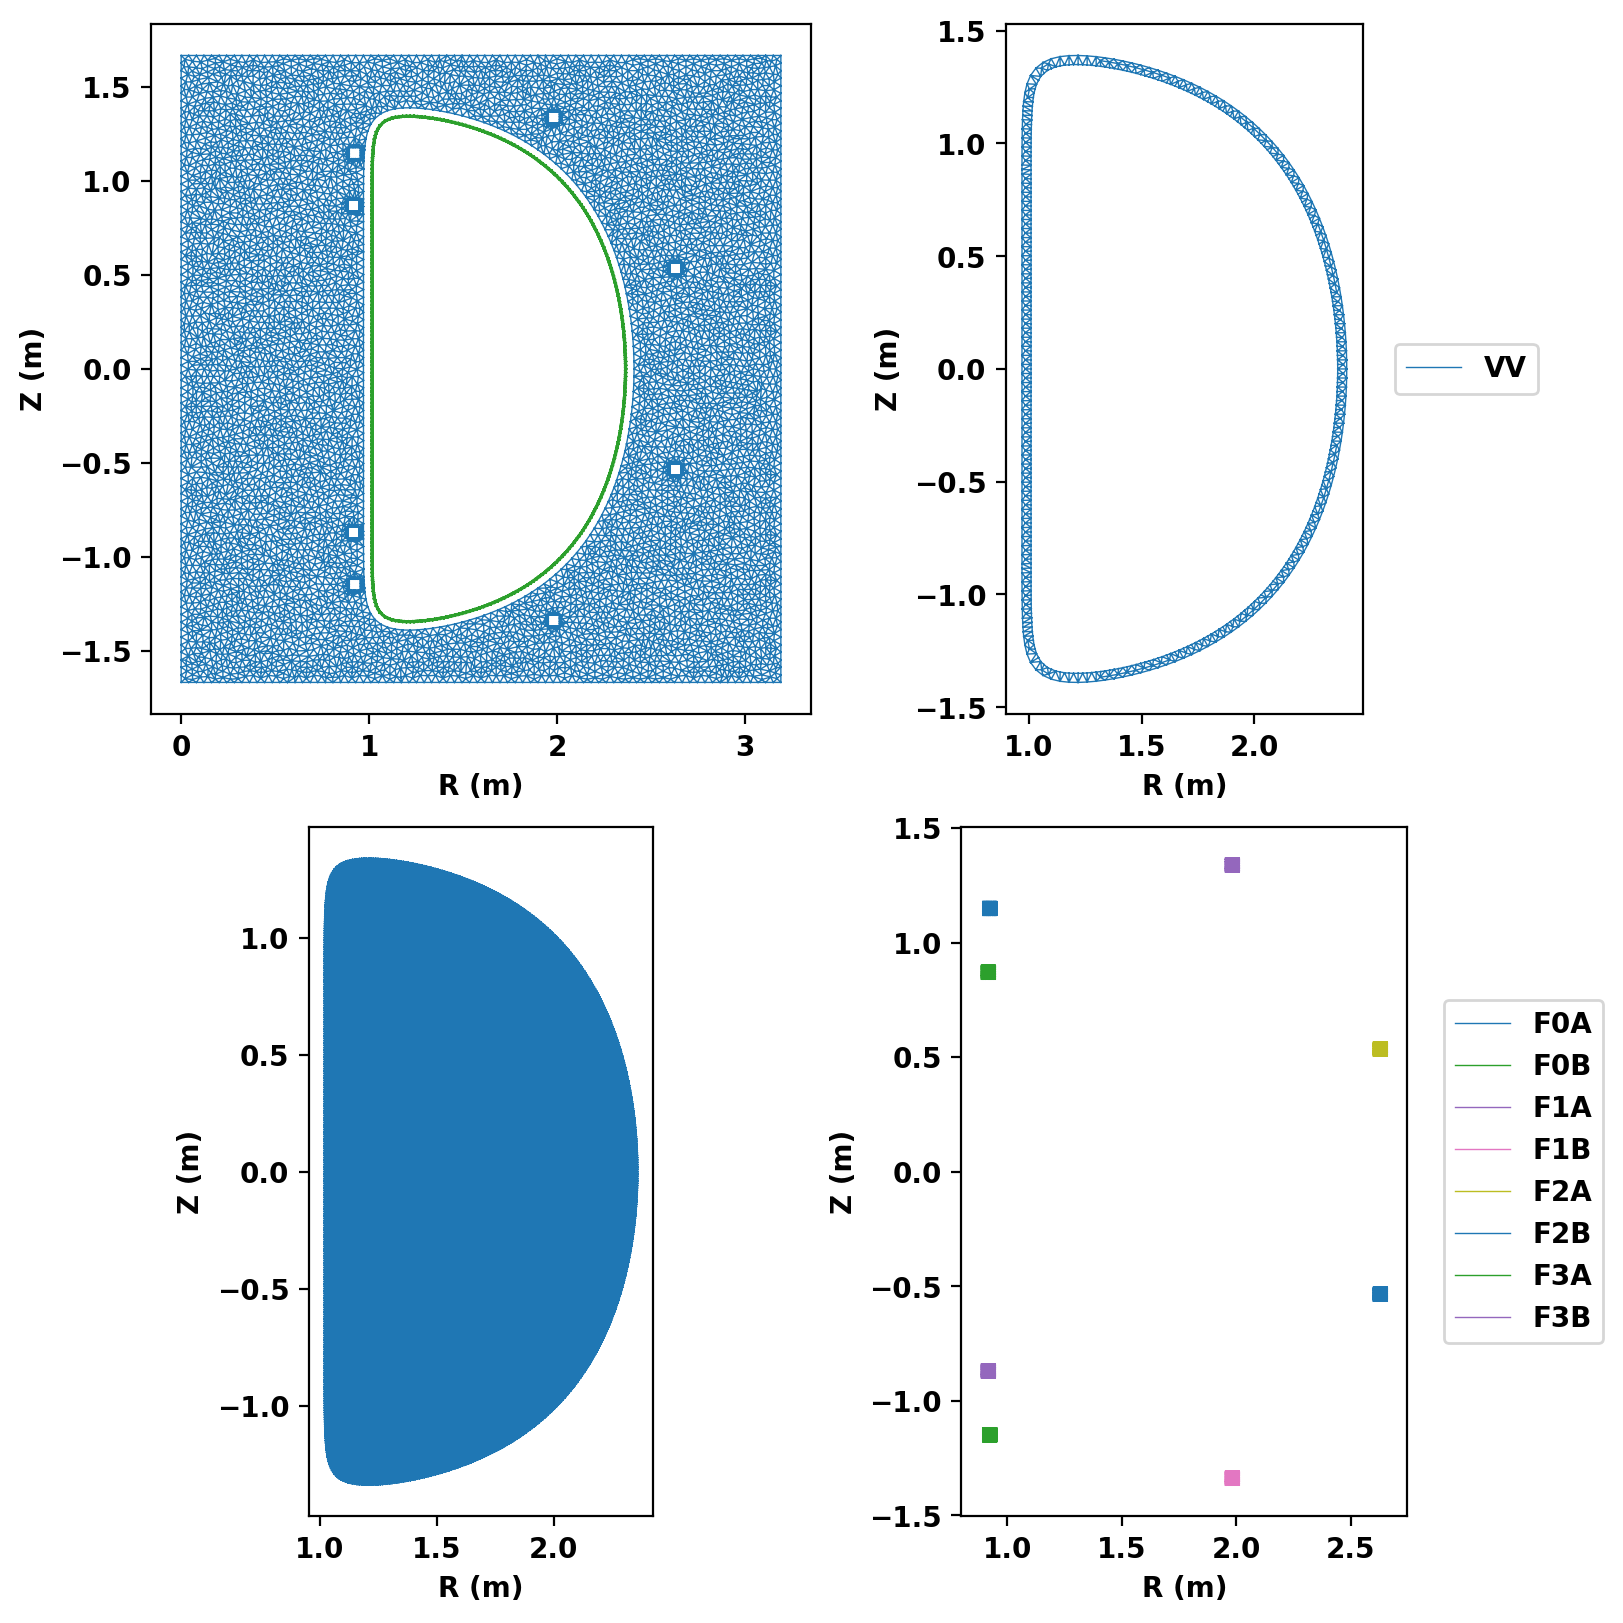

In [14]:
coil_dict_sol, cond_dict_sol = make_mesh(DIIID_geom, scan_geom_DIIID, savename = 'DIIID_mesh_scantest_withSolenoid.h5')

In [15]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('DIIID_mesh_scantest_withSolenoid.h5')
mygs.setup_mesh(mesh_pts,mesh_lc,mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.free_boundary = True # free boundary

F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2,F0=F0) # F0: vacuum F value

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          e2083e8
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/oft_89991/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.065E+01
    # of points  =   56337
    # of edges   =  168684
    # of cells   =  112348
    # of boundary points =     324
    # of boundary edges  =     324
    # of boundary cells  =     324
  Resolution statistics:
    hmin =  3.111E-03
    hrms =  1.563E-02
    hmax =  6.304E-02
  Surface grounded at vertex    1699


**** Creating

In [16]:
fixed_mag_axis = np.array([ 1.77764093, -0.04014656])
Ip_target = eqdsk['ip']
R0_target = fixed_mag_axis[0].item()
Z0 = fixed_mag_axis[1].item()
mygs.set_targets(Ip=Ip_target, R0=R0_target, V0=Z0)

### Define hard limits on coil currents
coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

In [17]:
err_flag = mygs.init_psi()

In [18]:
mygs.solve()

Starting non-linear GS solver
 DGETRF           1
 Timing:   7.4830999947153032E-002
   Source:     4.0047999995294958E-002
   Solve:      2.9848000034689903E-002
   Boundary:   0.0000000000000000     
   Other:      4.9349999171681702E-003


ValueError: Error in solve: Matrix solve failed for targets         

/Users/alt2005/OpenFUSIONToolkit/install_release/python/OpenFUSIONToolkit/TokaMaker/_core.py:771: RuntimeWarning: invalid value encountered in scalar divide
  li = (Bp_vol/vol)/numpy.power(mu0*Ip/dl,2)
/Users/alt2005/OpenFUSIONToolkit/install_release/python/OpenFUSIONToolkit/TokaMaker/_core.py:793: RuntimeWarning: invalid value encountered in scalar divide
  'kappa': (zbounds[1,1]-zbounds[0,1])/(rbounds[1,0]-rbounds[0,0]),
/Users/alt2005/OpenFUSIONToolkit/install_release/python/OpenFUSIONToolkit/TokaMaker/_core.py:794: RuntimeWarning: divide by zero encountered in scalar divide
  'kappaU': (zbounds[1,1]-self.o_point[1])*2.0/(rbounds[1,0]-rbounds[0,0]),
/Users/alt2005/OpenFUSIONToolkit/install_release/python/OpenFUSIONToolkit/TokaMaker/_core.py:795: RuntimeWarning: divide by zero encountered in scalar divide
  'kappaL': (self.o_point[1]-zbounds[0,1])*2.0/(rbounds[1,0]-rbounds[0,0]),
/Users/alt2005/OpenFUSIONToolkit/install_release/python/OpenFUSIONToolkit/TokaMaker/_core.py:796: Runtime

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    0.0000E+00
  Current Centroid [m]    =      NAN    NAN
  Magnetic Axis [m]       =   -1.000 999999999999999967336168804116691273849533185806555472917961779471295845921727862608739868455469056.000
  Elongation              =      NAN (U:   -INF, L:    INF)
  Triangularity           =      NAN (U:    NAN, L:    NAN)
  Plasma Volume [m^3]     =   30.000
  q_0, q_95               =    0.000  0.000
  Plasma Pressure [Pa]    =   Axis:  1.0329E+05, Peak:  1.0329E+05
  Stored Energy [J]       =    0.0000E+00
  <Beta_pol> [%]          =       NAN
  <Beta_tor> [%]          =    0.0000
  <Beta_n>   [%]          =       NAN
  Diamagnetic flux [Wb]   =    0.0000E+00
  Toroidal flux [Wb]      =    6.3076E+00
  l_i                     =       NAN


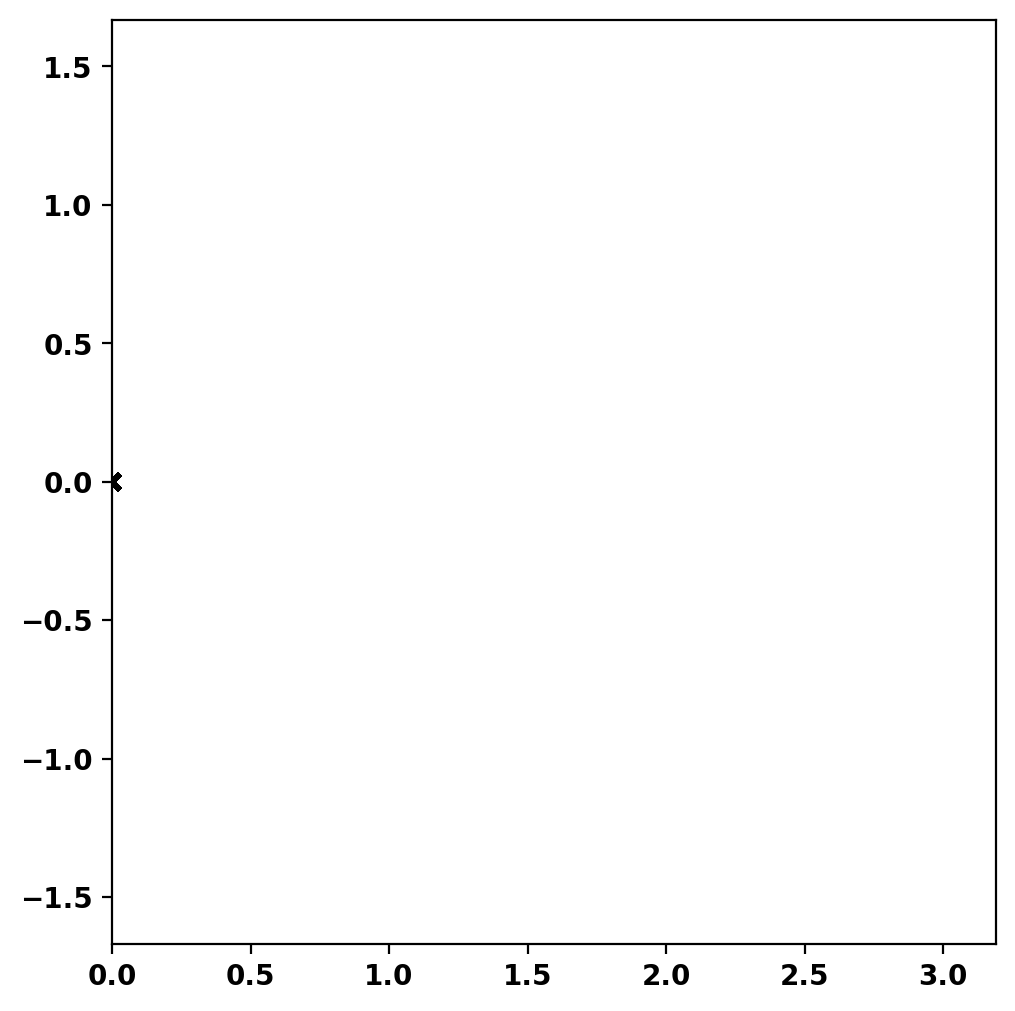

: 

In [ ]:
mygs.print_info()
# Plot flux surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_psi(fig,ax)

In [ ]:
r_bnd, psi_bnd = mygs.get_vfixed()
# Plot required relative flux on boundary
fig, ax = plt.subplots()
theta = np.arctan2(r_bnd[:,1],r_bnd[:,0]-mygs.o_point[0])
_=ax.plot(theta[1:],psi_bnd[1:]-psi_bnd[0],'+')


#----------------------------------------------
ERROR: Equilibrium is free-boundary
SUBROUTINE: gs_fixed_vflux
FILE: /Users/alt2005/OpenFUSIONToolkit/src/physics/grad_shaf.F90
#----------------------------------------------



# 4. Compute free-boundary solution with new coils

Vertical stability coils. Shouldn't be necessary for this case.

In [ ]:
#mygs.set_coil_vsc({'F1A': 1.0, 'F1B': -1.0})

`fixed_mag_axis` is obtained by constructing the target equilibrium with TokaMaker in the fixed case. Choose one of the below ones depending on the considered equilibrium
- $\textbf{g192185.02440}$: `fixed_mag_axis` = np.array([ 1.77764093, -0.04014656])
- $\textbf{g174864.02500}$: `fixed_mag_axis` = np.array([1.74028708, 0.02673819])
- $\textbf{g173630.03000}$: `fixed_mag_axis` = np.array([ 1.79456678, -0.04926767])

In [ ]:
fixed_mag_axis = np.array([ 1.77764093, -0.04014656])
Ip_target = eqdsk['ip']
R0_target = fixed_mag_axis[0].item()
Z0 = fixed_mag_axis[1].item()
mygs.set_targets(Ip=Ip_target, R0=R0_target, V0=Z0)

### Define hard limits on coil currents
coil_bounds = {key: [-6.E8, 6.E8] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

### X-point

Determine X-point index in LCFS and set the corresponding weight. Tune `index` to find the X-point 

X-point indices (on LCFS) for DIII-D equilibria:
- $\textbf{g192185.02440}$: index = 55
- $\textbf{g174864.02500}$: index = 68 
- $\textbf{g173630.03000}$: index = 69

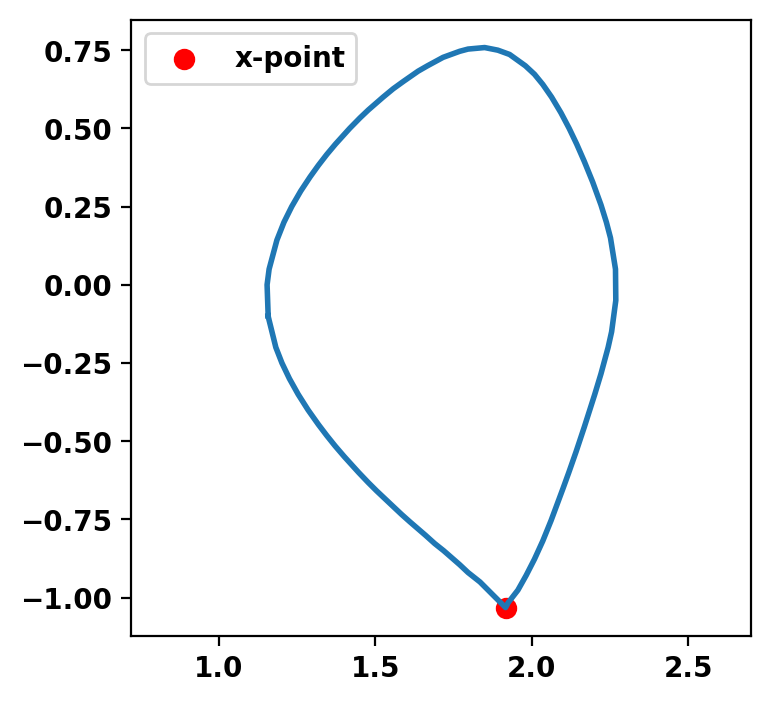

In [ ]:
isoflux_pts = eqdsk['rzout'].copy()
index = 55 # tune

plt.figure(figsize=(4, 4))
plt.plot(isoflux_pts[:,0], isoflux_pts[:,1])
plt.scatter(isoflux_pts[index][0], isoflux_pts[index][1], color='r', s=45, label="x-point")
plt.axis('equal')
plt.legend()

Set the X-point weight

In [ ]:
weights = np.ones(len(isoflux_pts[:,0]))
weights[index] = 1e4 # X-point weight
mygs.set_isoflux(isoflux_pts, weights=weights)

### Current targets

Set current and weight targets for solenoids and PF coils

In [ ]:
def set_regularization(gs_obj, solenoid_target, weight_curr=1.E-2):
    regularization_terms = []
    for name, coil in mygs.coil_sets.items():
        if name.find('E0') >= 0 or name.find('E1') >= 0: # We will set everything for upper coils
            regularization_terms.append(mygs.coil_reg_term({name: 1.0}, target=solenoid_target, weight=1.E4)) # fixing solenoid currents (not allowing them to change too much)
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=weight_curr)) # fixing coil currents to 0 but allowing them to move
    
    # Pass regularization terms to TokaMaker
    gs_obj.set_coil_reg(reg_terms=regularization_terms)

In [ ]:
coil_names = list(mygs.coil_sets.keys())

# Fixing solenoid targets
target_solenoid1 = -0.977888676757812E6
target_solenoid2 = -0.962711173828125E6

solenoid_targets = np.array([target_solenoid1, target_solenoid2])
coil_currents = np.zeros((len(solenoid_targets), len(coil_names)))

init psi for different DIII-D equilibria:
- $\textbf{g192185.02440}$: mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288) 
- $\textbf{g174864.02500}$: mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.679, delta=0.318)
- $\textbf{g173630.03000}$: mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.821, delta=0.467)

Depending on the considered equilibrium, used one of the above lines in the below cell

Coil currents can be very sensitive to `weight`. Used range: 1e-1 - 1e-3

In [ ]:
# Weight for PF coils to be 0
weight = 3.E-2

# Setting regularization
for i, solenoid_target in enumerate(solenoid_targets):
    set_regularization(mygs, solenoid_target, weight)
    mygs.init_psi(r0=1.8, z0=-0.040, a=0.45, kappa=1.547, delta=-0.288) 
    err_flag = mygs.solve()

    currents, currents_reg = mygs.get_coil_currents()
    coil_currents[i] = np.array([currents[name] for name in coil_names])

Starting non-linear GS solver
     1  2.1070E-03  2.1778E-01  6.6182E-04  1.8175E+00 -3.8769E-02 -0.0000E+00
     2  4.1833E-01  1.5260E-01  2.2320E-04  1.8099E+00 -3.9196E-02 -0.0000E+00


     3  5.8642E-01  1.2521E-01  1.8328E-04  1.8018E+00 -3.9457E-02 -0.0000E+00
     4  6.8902E-01  1.0808E-01  1.4667E-04  1.7954E+00 -3.9616E-02 -0.0000E+00
     5  7.7310E-01  9.3956E-02  1.1911E-04  1.7903E+00 -3.9711E-02 -0.0000E+00
     6  8.5118E-01  8.0821E-02  1.0318E-04  1.7857E+00 -3.9771E-02 -0.0000E+00
     7  9.2697E-01  6.8064E-02  9.5082E-05  1.7814E+00 -3.9808E-02 -0.0000E+00
     8  9.4311E-01  6.5217E-02  5.2651E-05  1.7792E+00 -3.9827E-02 -0.0000E+00
     9  9.4669E-01  6.4546E-02  2.5195E-05  1.7783E+00 -3.9836E-02 -0.0000E+00
    10  9.4751E-01  6.4379E-02  1.1274E-05  1.7779E+00 -3.9840E-02 -0.0000E+00
    11  9.4769E-01  6.4335E-02  4.8582E-06  1.7777E+00 -3.9841E-02 -0.0000E+00
    12  9.4774E-01  6.4322E-02  2.0441E-06  1.7777E+00 -3.9842E-02 -0.0000E+00
    13  9.4774E-01  6.4319E-02  8.4611E-07  1.7777E+00 -3.9842E-02 -0.0000E+00
 Timing:  0.99675799999386072     
   Source:    0.49158199998782948     
   Solve:     0.40906500007258728     
   Boundary:   1.6

### Plotting Free-Boundary solution

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    4.9333E+05
  Current Centroid [m]    =    1.736 -0.052
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.577 (U:  1.422, L:  1.732)
  Triangularity           =   -0.299 (U: -0.223, L: -0.376)
  Plasma Volume [m^3]     =   14.578
  q_0, q_95               =    2.860  5.675
  Plasma Pressure [Pa]    =   Axis:  6.9282E+03, Peak:  6.9282E+03
  Stored Energy [J]       =    5.2136E+04
  <Beta_pol> [%]          =   30.6505
  <Beta_tor> [%]          =    0.1663
  <Beta_n>   [%]          =    0.3582
  Diamagnetic flux [Wb]   =    5.1594E-03
  Toroidal flux [Wb]      =    2.5435E+00
  l_i                     =    0.8045


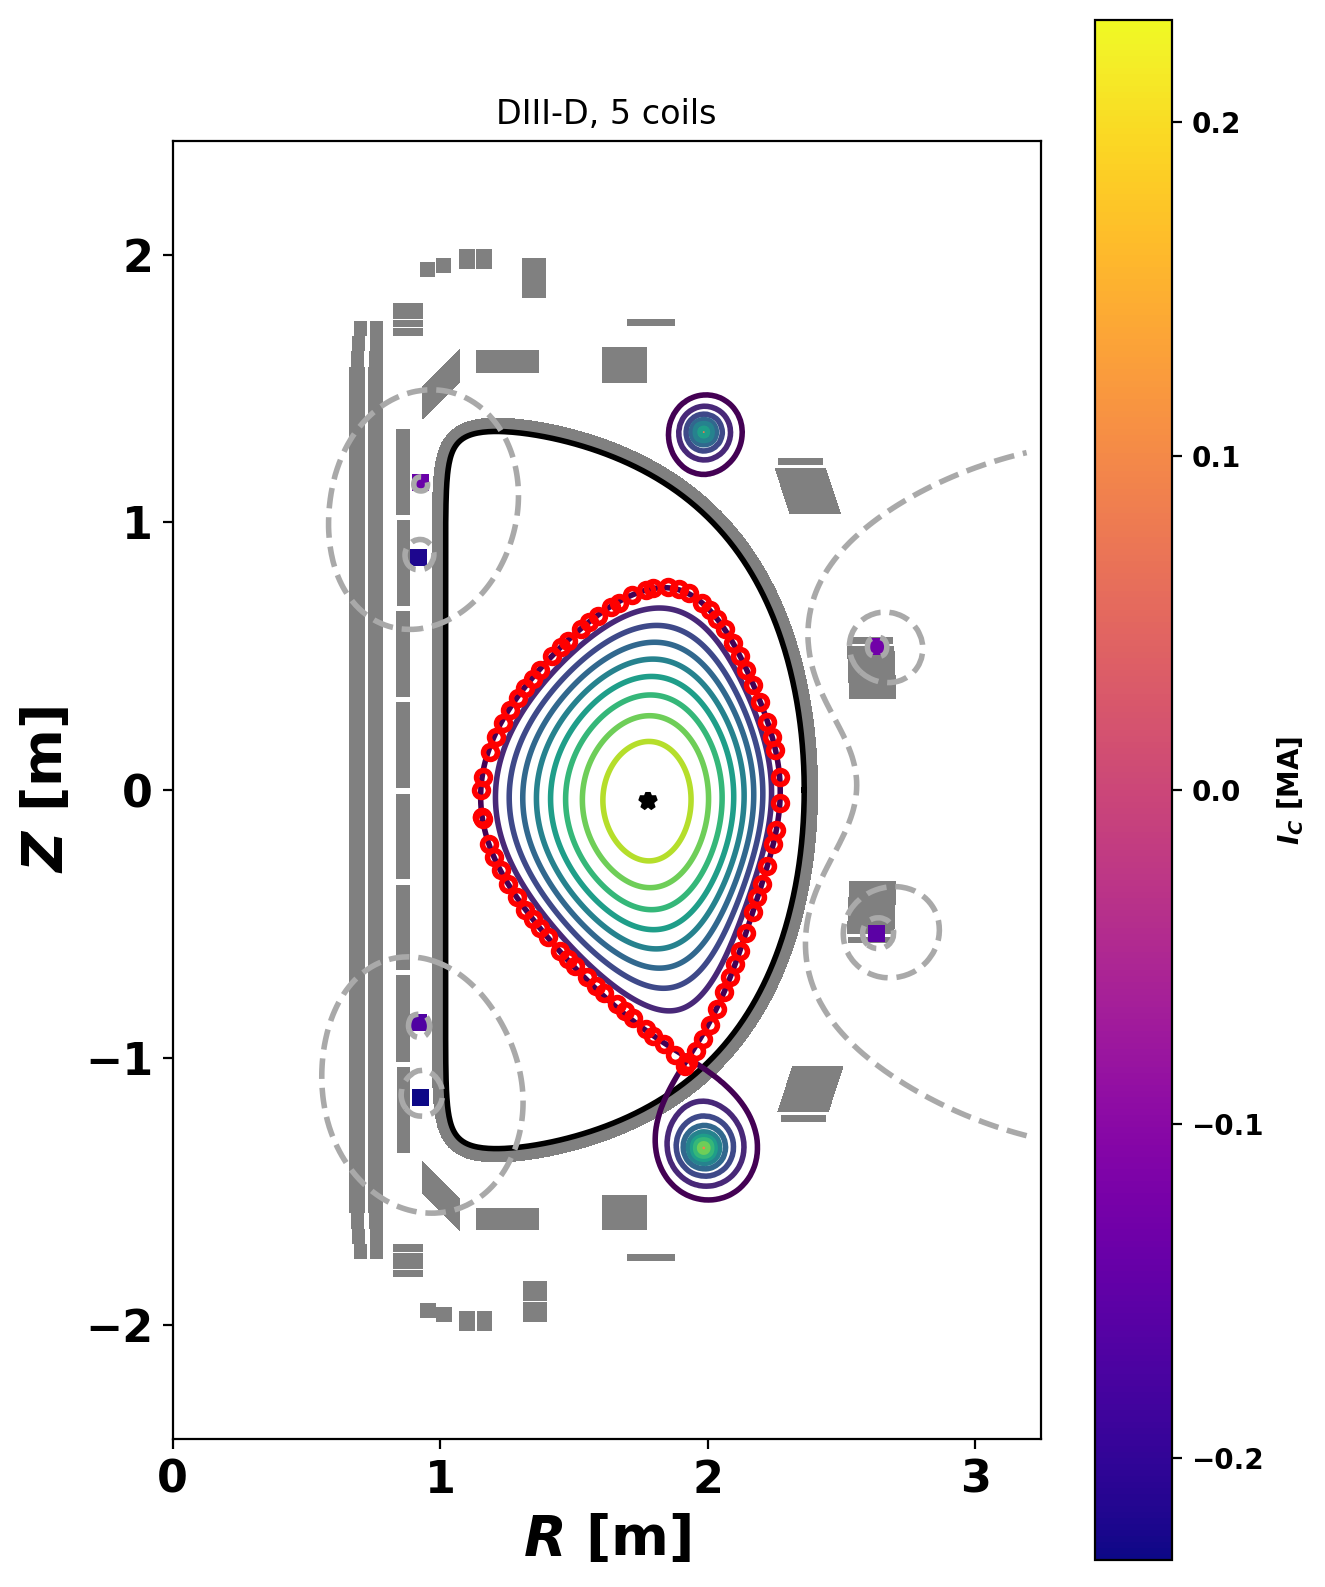

In [ ]:
## Plot the final solution just for kicks
mygs.print_info()

fig, ax = plt.subplots(1,1,figsize=(7,10))

# Plot DIII-D baseline geometry
mask_vals = np.ones((mygs2.np,))
for _, coil_reg in mygs2._coil_dict.items():
    mask_tmp = (mygs2.reg == coil_reg['reg_id'])
    ax.tricontourf(mygs2.r[:,0], mygs2.r[:,1], mygs2.lc[mask_tmp,:], mask_vals, colors='grey', alpha=1)
    
# Plot solution
mygs.plot_machine(fig,ax,coil_colormap='plasma',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]', vacuum_color=None)
mygs.plot_psi(fig,ax,xpoint_color=None,plasma_nlevels=10,vacuum_nlevels=4)
ax.plot(LCFS_contour[:,0],LCFS_contour[:,1],'ro',fillstyle='none', markersize=5)
ax.set_title(r'DIII-D, 5 coils')

ax.set_xlabel(r'$R$ [m]', fontsize=20)
ax.set_ylabel(r'$Z$ [m]', fontsize=20)
ax.tick_params(labelsize=16)

## Computing & visualizing currents

In [ ]:
DIIID_currents, DIIID_currents_reg = mygs.get_coil_currents()
DIIID_currents

{'F0A': np.float64(-138777.76022821717),
 'F0B': np.float64(-230432.69465897768),
 'F1A': np.float64(79734.94171251667),
 'F1B': np.float64(94253.02799110561),
 'F2A': np.float64(-130013.58348962256),
 'F2B': np.float64(-156450.46627545348),
 'F3A': np.float64(-218345.43257342372),
 'F3B': np.float64(-168015.9358626492)}

Comparison between total current from optimized and baseline currents

In [ ]:
excluded_keys = {'E0', 'E1'}
tot_PFcurrs = sum(abs(val) for key, val in DIIID_currents.items() if key not in excluded_keys)
tot_PFcurrs # total current from optimized currents

np.float64(1216023.842791966)